# US17 — Top 10 Empresas com Maior Valor de Ações Detidas por Agentes Políticos

**Descrição:**  
Como membro do Comité de Ética, quero obter um gráfico que apresente as dez empresas com os maiores valores totais de ações detidas por agentes políticos, juntamente com os respetivos montantes. Para cada agente político, apenas a declaração mais recente será considerada.

---

## Conceitos Teóricos Aplicados

### Frequência Absoluta
O valor total de ações por empresa é obtido somando os valores de todos os agentes que detêm ações nessa empresa (usando apenas a declaração mais recente de cada agente):

$$n_i = \sum_{j=1}^{k} \text{total\_value\_in\_stocks}_{ij}$$

onde $k$ é o número de agentes com posições na empresa $i$.

### Ranking / Ordenação
Após calcular o valor total por empresa, ordenamos de forma decrescente e selecionamos as 10 primeiras — correspondendo às empresas com maior exposição a ativos de agentes políticos.

### Gráfico de Barras
Representação em que cada barra tem altura proporcional à frequência (valor total) da categoria correspondente, permitindo comparação visual directa entre empresas.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/dataset2_holdings.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

print(f"Dataset carregado: {df.shape[0]} registos")
print(f"Agentes únicos  : {df['agent_id'].nunique()}")
print(f"Empresas únicas : {df['company_NIF'].nunique()}")
print()
print(df.head())

Dataset carregado: 953 registos
Agentes únicos  : 135
Empresas únicas : 92

  agent_id  company_NIF  total_value_in_stocks  company_percentage  \
0   A00128    100000066              157039.75               11.42   
1   A00128    100000066              158976.75                2.95   
2   A00128    100000066              160913.75               11.75   
3   A00092    100000031              145789.76                0.52   
4   A00092    100000031              151637.13               24.81   

  declaration_date  
0       2020-05-10  
1       2021-02-04  
2       2021-07-18  
3       2018-05-11  
4       2020-02-09  


## 1. Selecção da Declaração Mais Recente por Agente

Conforme especificado no enunciado, para cada agente político considera-se apenas a declaração mais recente.  
Como um agente pode ter ações em várias empresas na mesma data, seleccionamos todos os registos cuja data corresponde à data máxima do agente.

In [2]:
# ── Data mais recente por agente ────────────────────────────────────────────
data_mais_recente = (
    df.groupby('agent_id')['declaration_date']
    .max()
    .reset_index()
    .rename(columns={'declaration_date': 'max_date'})
)

# Juntar ao dataset original para filtrar apenas os registos mais recentes
df_recente = df.merge(data_mais_recente, on='agent_id')
df_recente = df_recente[df_recente['declaration_date'] == df_recente['max_date']].copy()

print(f"Registos antes do filtro : {df.shape[0]}")
print(f"Registos após filtro     : {df_recente.shape[0]}")
print(f"Agentes representados    : {df_recente['agent_id'].nunique()}")

Registos antes do filtro : 953
Registos após filtro     : 136
Agentes representados    : 135


## 2. Cálculo do Valor Total de Ações por Empresa

Somamos o `total_value_in_stocks` de todos os agentes para cada empresa, usando apenas as declarações mais recentes.

In [3]:
# ── Valor total por empresa ─────────────────────────────────────────────────
valor_por_empresa = (
    df_recente.groupby('company_NIF')['total_value_in_stocks']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
valor_por_empresa.columns = ['company_NIF', 'total_value']

# Número de agentes por empresa (informação adicional)
agentes_por_empresa = (
    df_recente.groupby('company_NIF')['agent_id']
    .nunique()
    .reset_index()
    .rename(columns={'agent_id': 'n_agents'})
)
valor_por_empresa = valor_por_empresa.merge(agentes_por_empresa, on='company_NIF')

# Top 10
top10 = valor_por_empresa.head(10).copy()
top10['company_NIF'] = top10['company_NIF'].astype(str)  # NIF como string para o eixo

print("TOP 10 EMPRESAS — VALOR TOTAL DE AÇÕES DETIDAS POR AGENTES POLÍTICOS")
print("=" * 65)
print(f"{'Rank':<5} {'NIF Empresa':<15} {'Valor Total (€)':>18} {'Nº Agentes':>12}")
print("-" * 55)
for i, row in top10.iterrows():
    rank = valor_por_empresa.index.get_loc(i) + 1
    print(f"{rank:<5} {row['company_NIF']:<15} {row['total_value']:>18,.2f} {row['n_agents']:>12}")

TOP 10 EMPRESAS — VALOR TOTAL DE AÇÕES DETIDAS POR AGENTES POLÍTICOS
Rank  NIF Empresa        Valor Total (€)   Nº Agentes
-------------------------------------------------------
1     100000031               661,372.12            5
2     100000069               626,334.79            4
3     100000064               564,134.33            3
4     100000040               552,342.37            2
5     100000000               511,550.02            2
6     100000080               484,236.94            4
7     100000091               470,563.11            2
8     100000010               467,310.70            3
9     100000068               458,345.84            3
10    100000058               440,384.11            3


## 3. Gráfico — Top 10 Empresas por Valor Total de Ações

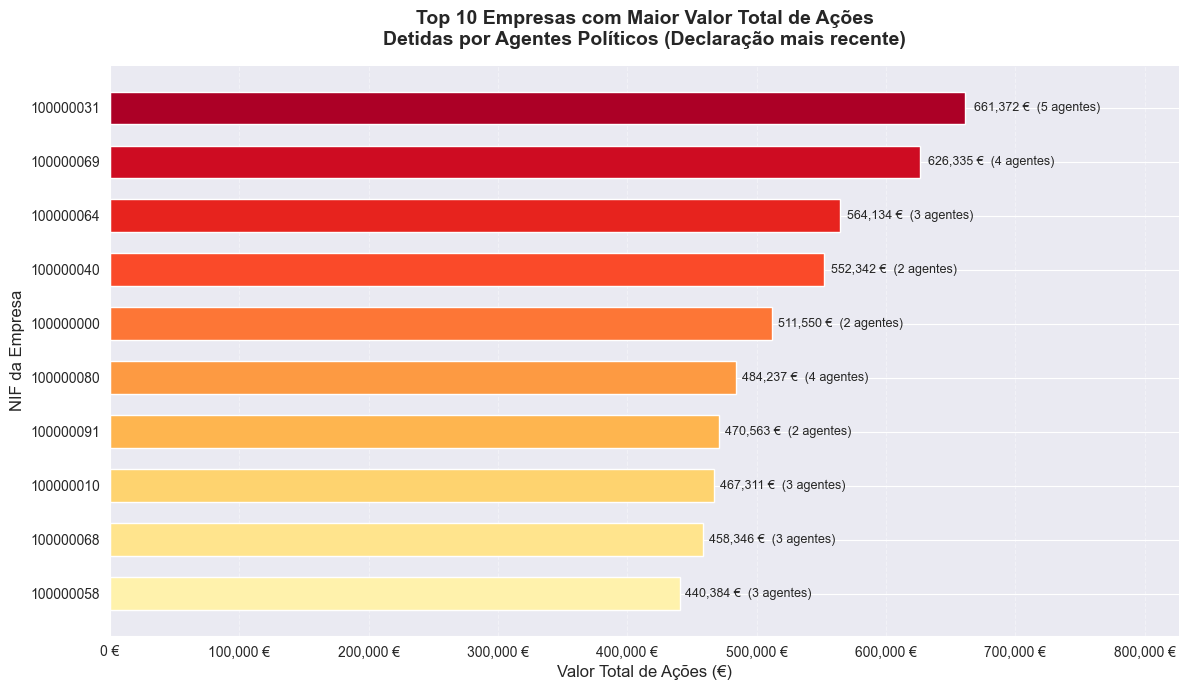

Gráfico guardado em: US17_top10_empresas_acoes.svg


In [4]:
# ── Gráfico de barras horizontais ───────────────────────────────────────────
# Barras horizontais facilitam a leitura dos NIFs e a comparação de valores

fig, ax = plt.subplots(figsize=(12, 7))

cores = sns.color_palette('YlOrRd', n_colors=10)[::-1]  # mais escuro = maior valor

barras = ax.barh(
    y=top10['company_NIF'],
    width=top10['total_value'],
    color=cores,
    edgecolor='white',
    height=0.6
)

# Ordenar do maior para o menor (de cima para baixo)
ax.invert_yaxis()

# Anotação do valor em cada barra
for barra, (_, row) in zip(barras, top10.iterrows()):
    ax.text(
        barra.get_width() + barra.get_width() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{row['total_value']:,.0f} €  ({row['n_agents']} agentes)",
        va='center', ha='left', fontsize=9
    )

ax.set_title(
    'Top 10 Empresas com Maior Valor Total de Ações\nDetidas por Agentes Políticos (Declaração mais recente)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Valor Total de Ações (€)', fontsize=12)
ax.set_ylabel('NIF da Empresa', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
ax.set_xlim(0, top10['total_value'].max() * 1.25)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('US17_top10_empresas_acoes.svg', format='svg', bbox_inches='tight')
plt.show()
print("Gráfico guardado em: US17_top10_empresas_acoes.svg")

## 4. Interpretação dos Resultados

In [5]:
# ── Interpretação automática ────────────────────────────────────────────────
empresa_topo   = top10.iloc[0]
empresa_fundo  = top10.iloc[9]
total_top10    = top10['total_value'].sum()
total_geral    = valor_por_empresa['total_value'].sum()
pct_top10      = total_top10 / total_geral * 100

print("INTERPRETAÇÃO")
print("-" * 60)
print(f"• Empresa com maior exposição : NIF {empresa_topo['company_NIF']}")
print(f"  Valor total                 : {empresa_topo['total_value']:,.2f} €")
print(f"  Nº de agentes com posições  : {empresa_topo['n_agents']}")
print()
print(f"• O Top 10 representa {pct_top10:.1f}% do valor total de ações")
print(f"  declaradas por todos os agentes políticos ({total_geral:,.2f} €).")
print()
print(f"• Empresas com muitos agentes políticos como detentores de ações")
print(f"  e/ou com valores muito elevados podem constituir potenciais")
print(f"  conflitos de interesse a investigar pelo Comité de Ética.")

INTERPRETAÇÃO
------------------------------------------------------------
• Empresa com maior exposição : NIF 100000031
  Valor total                 : 661,372.12 €
  Nº de agentes com posições  : 5

• O Top 10 representa 32.9% do valor total de ações
  declaradas por todos os agentes políticos (15,905,829.37 €).

• Empresas com muitos agentes políticos como detentores de ações
  e/ou com valores muito elevados podem constituir potenciais
  conflitos de interesse a investigar pelo Comité de Ética.
